# Lecture 19 - Exercise - The Quasar dataset part I

In [155]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

#-------------------------------------------------------------------------
# maths 

import numpy                        as np
import pandas                       as pd
from   numpy.random                 import default_rng
from   scipy                        import stats, integrate, special
from   astroML                      import stats as astroMLstats

#-------------------------------------------------------------------------
# plotting 

import matplotlib                   as mpl
import matplotlib.pyplot            as plt
import corner
from   astropy.visualization.hist   import hist  as fancyhist
from   mycolorpy                    import colorlist as mcp
from   matplotlib                   import rc

#-------------------------------------------------------------------------
# parameter estimation with posterior sampling (MCMC, nested...)

import emcee
import dynesty
from   dynesty                      import utils as dyfunc
from   dynesty                      import plotting as dyplot

#-------------------------------------------------------------------------
# linear regression

from   astroML.linear_model         import PolynomialRegression, BasisFunctionRegression, NadarayaWatson

#-------------------------------------------------------------------------
# sklearn density estimation and dimensionality reduction

from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap, TSNE
from   sklearn.model_selection      import train_test_split, learning_curve, GridSearchCV, cross_val_predict
from   sklearn.gaussian_process     import GaussianProcessRegressor, kernels
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA

#-------------------------------------------------------------------------
# classifiers 

from   sklearn.metrics               import confusion_matrix, accuracy_score, precision_score, recall_score
from   sklearn.cluster               import KMeans
from   sklearn.neighbors             import KNeighborsClassifier
from   sklearn.naive_bayes           import GaussianNB
from   sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from   sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from   astroML.classification        import GMMBayes
from   astroML.utils                 import split_samples, completeness_contamination

#-------------------------------------------------------------------------
# standard utility

import os
from   sys                          import stdout

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

d:\Documents\University\Magistrale\Statistics\GitHub\working


In [20]:
# file_data = '..\solutions\galaxyquasar.csv'
# data = np.genfromtxt(file_data, delimiter=',',names=True, usecols=(0,1,2,3,4,6),dtype=float,comments='#')
# names = data.dtype.names
# print(names)

In [ ]:
#-------------------------------------------------------------------------
# Load data with pandas (intermediate step) 
#-------------------------------------------------------------------------

file_data = '..\solutions\galaxyquasar.csv'
with open(file_data, 'rb') as file:
    data_pandas = pd.read_csv(file, sep=",")

N_samples = data_pandas.shape[0]

display(data_pandas)

#-------------------------------------------------------------------------

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [106]:
#-------------------------------------------------------------------------
# put data in comfy format for classification
#-------------------------------------------------------------------------

x = np.zeros((N_samples,4))

x[:,0] = data_pandas['u'] - data_pandas['g']
x[:,1] = data_pandas['g'] - data_pandas['r']
x[:,2] = data_pandas['r'] - data_pandas['i']
x[:,3] = data_pandas['i'] - data_pandas['z']

y = np.zeros(N_samples)

for i in range(N_samples):
    if   data_pandas['class'][i] == 'QSO':
        y[i] = 1
    elif data_pandas['class'][i] == 'GALAXY':
        y[i] = 0
    else: 
        y[i] = np.nan

index_QSR = y==1
index_GAL = y==0

#-------------------------------------------------------------------------

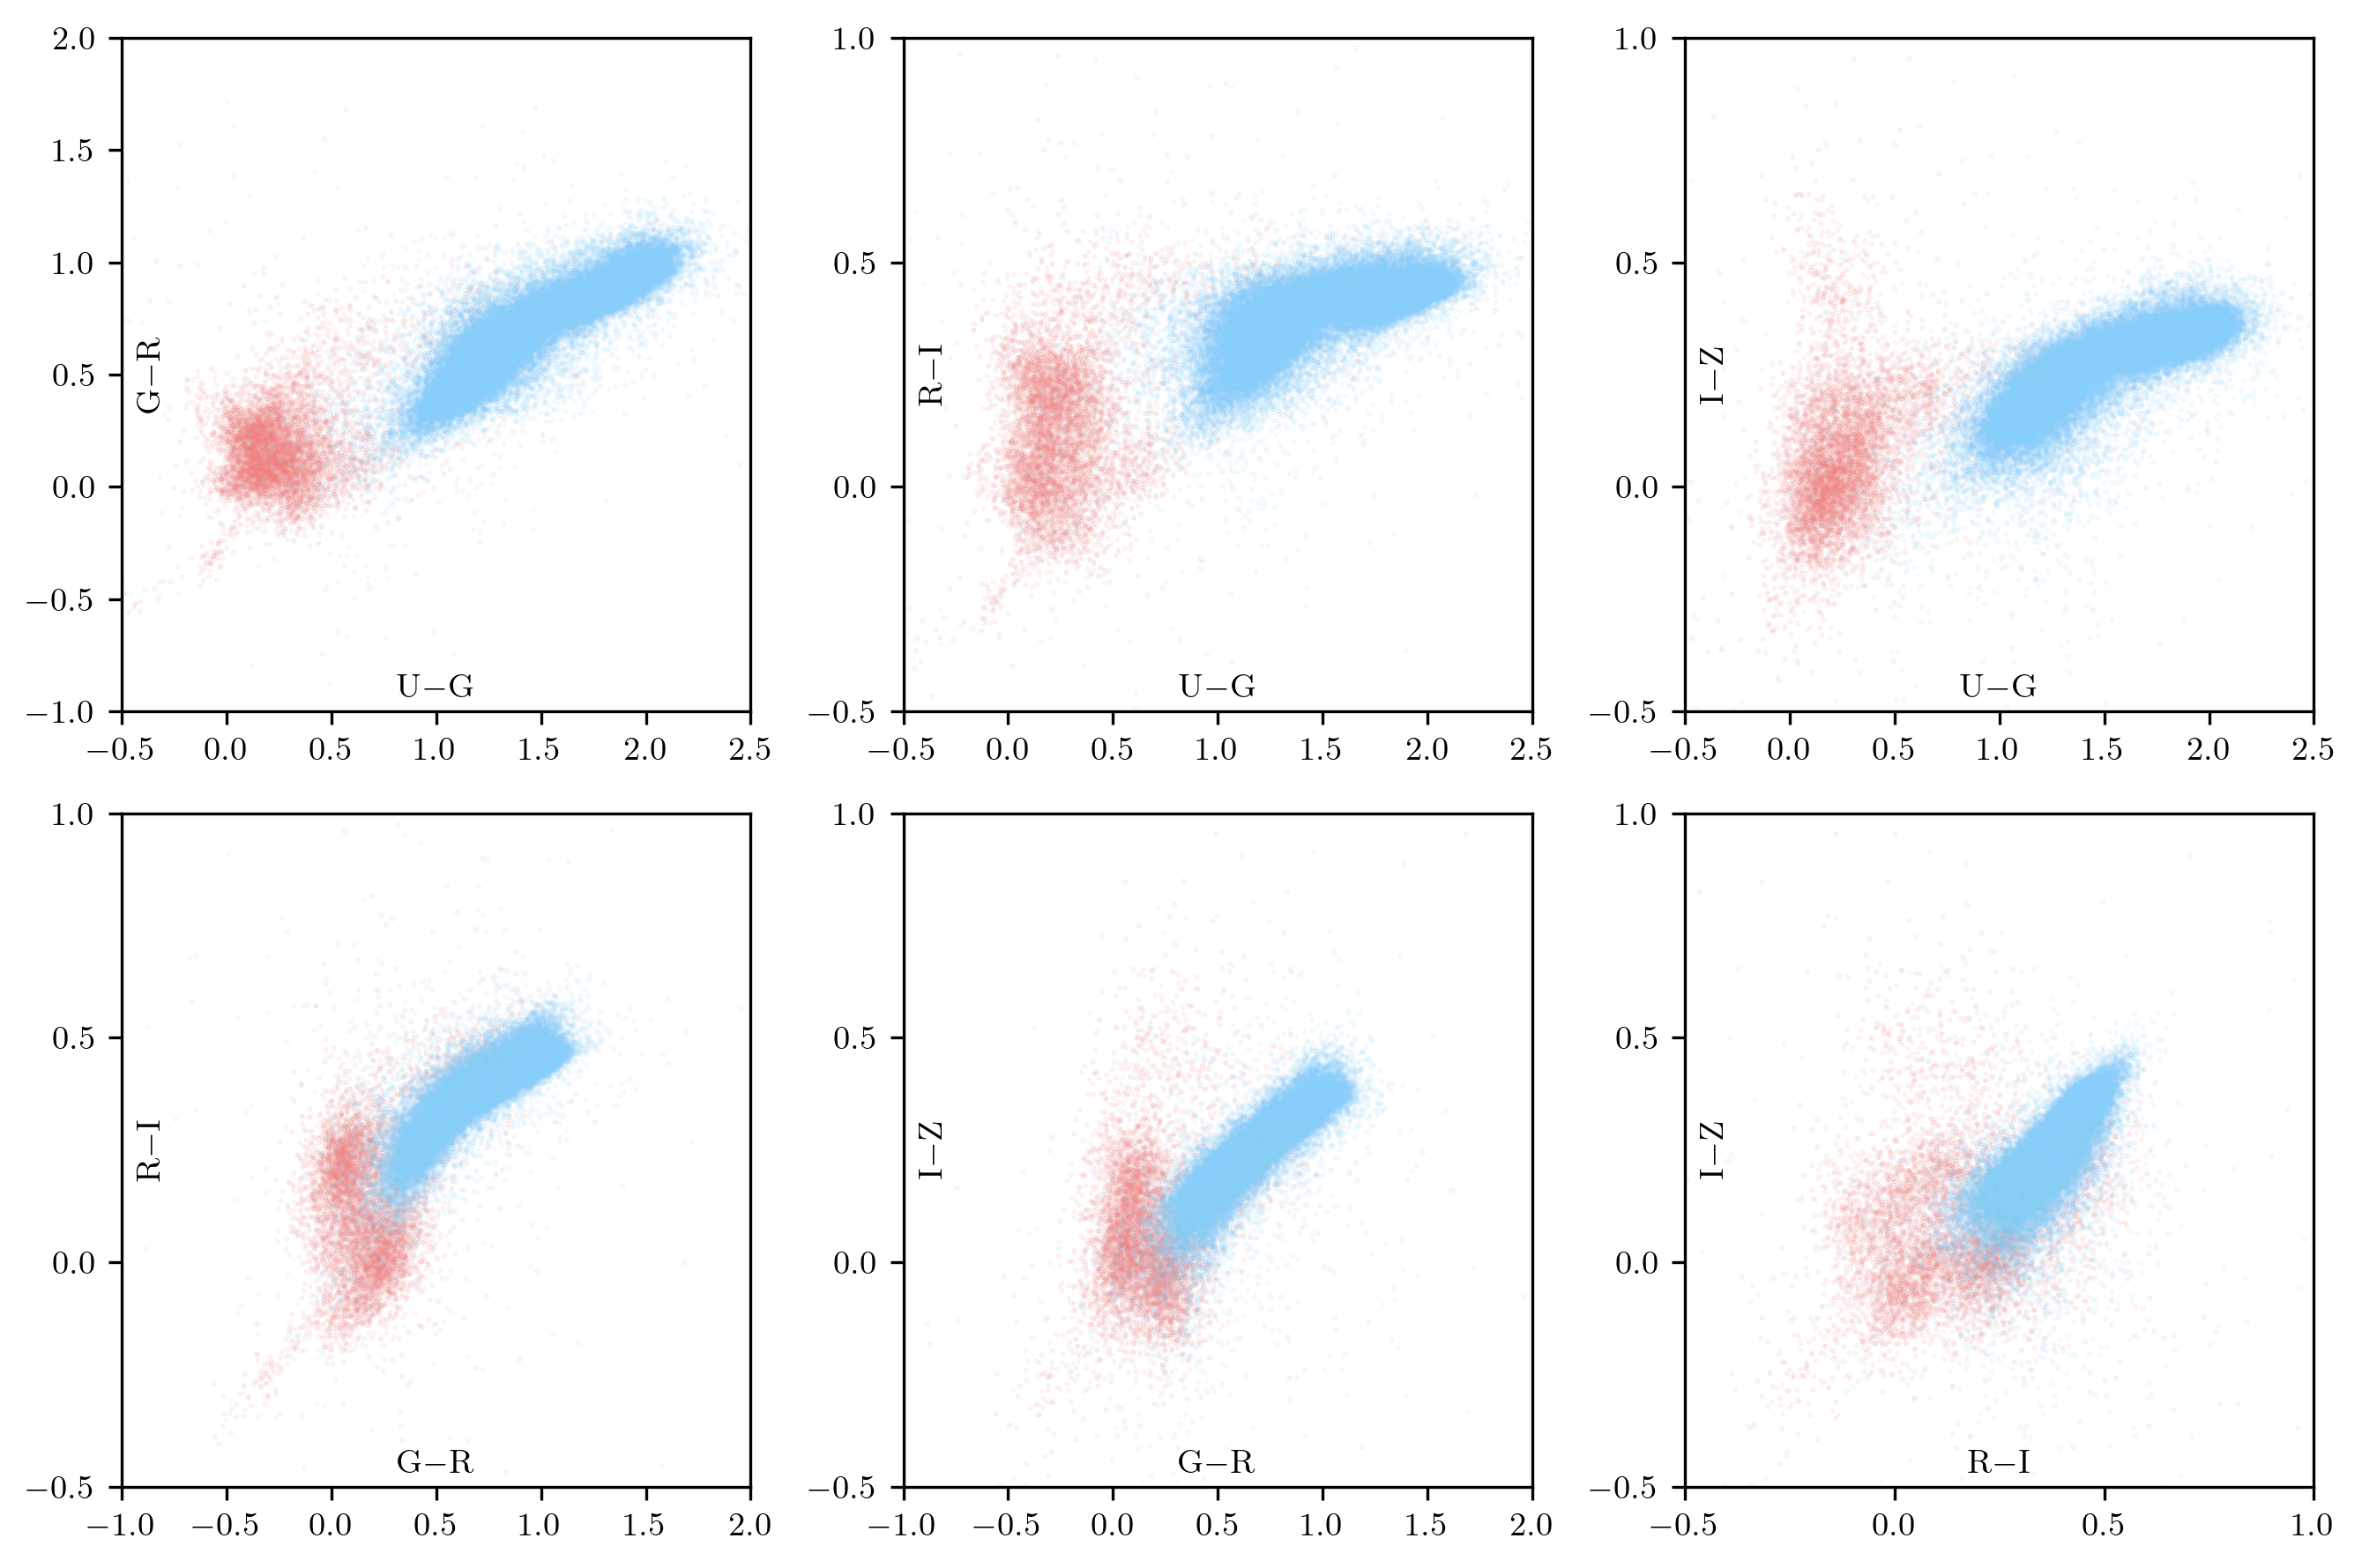

In [121]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(2,3,figsize=(9,6))

axlabels = ['U$-$G', 'G$-$R', 'R$-$I', 'I$-$Z']

lims = [(-0.5,+2.5),(-1,+2),(-0.5,+1),(-0.5,+1)]

for i in range(3):
    ax[0,i].set_xlim(lims[0])
    ax[0,i].set_ylim(lims[i+1])
    ax[0,i].set_xlabel(axlabels[0], labelpad=-25)
    ax[0,i].set_ylabel(axlabels[i+1], labelpad=-38)
    ax[0,i].scatter(x[index_QSR,0] , x[index_QSR,i+1] , color='lightcoral', s=0.1, alpha=0.15)
    ax[0,i].scatter(x[index_GAL,0] , x[index_GAL,i+1] , color='lightskyblue', s=0.1, alpha=0.15)

for i in range(2):
    ax[1,i].set_xlim(lims[1])
    ax[1,i].set_ylim(lims[i+2])
    ax[1,i].set_xlabel(axlabels[1], labelpad=-25)
    ax[1,i].set_ylabel(axlabels[i+2], labelpad=-38)
    ax[1,i].scatter(x[index_QSR,1] , x[index_QSR,i+2] , color='lightcoral', s=0.1, alpha=0.15)
    ax[1,i].scatter(x[index_GAL,1] , x[index_GAL,i+2] , color='lightskyblue', s=0.1, alpha=0.15)

ax[1,2].set_xlim(lims[2])
ax[1,2].set_ylim(lims[3])
ax[1,2].set_xlabel(axlabels[2], labelpad=-25)
ax[1,2].set_ylabel(axlabels[3], labelpad=-38)
ax[1,2].scatter(x[index_QSR,2] , x[index_QSR,3] , color='lightcoral', s=0.1, alpha=0.15)
ax[1,2].scatter(x[index_GAL,2] , x[index_GAL,3] , color='lightskyblue', s=0.1, alpha=0.15)

for i in range(2):
    for j in range(3):
        ax[i,j].xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax[i,j].yaxis.set_major_locator(plt.MultipleLocator(0.5))

fig.tight_layout()

#-------------------------------------------------------------------------

In [ ]:
print()

[1 2 3 4]


In [ ]:
#-------------------------------------------------------------------------
# GMMBayes classifier
#-------------------------------------------------------------------------

(x_train_GMMBayes, x_test_GMMBayes), (y_train_GMMBayes, y_test_GMMBayes) = split_samples(x, y, [0.75, 0.25])

# N_colors_GMMBayes = np.arange(1,5)
# N_comp_GMMBayes   = np.arange(1,7)

def compute_GMMBayes_list(N_colors, N_comp, x_train, y_train, x_test):
    classifiers = []
    predictions = []
    for component in N_comp:
        classifiers.append([])
        predictions.append([])
        for color in N_colors:
            clf = GMMBayes(component, tol=1E-5, covariance_type='full')
            clf.fit(x_train[:, :color], y_train)
            y_pred = clf.predict(x_test[:, :color])
            classifiers[-1].append(clf)
            predictions[-1].append(y_pred)
    return classifiers, predictions

def compute_GMMBayes(N_colors, N_comp, x_train, y_train, x_test):
    clf = GMMBayes(N_comp, tol=1E-5, covariance_type='full')
    clf.fit(x_train[:, :N_colors], y_train)
    y_pred = clf.predict(x_test[:, :N_colors])
    return clf, y_pred

N_colors_GMMBayes = 4 # np.arange(1,5)
N_comp_GMMBayes   = 5 # np.arange(1,7)

classifiers_GMMBayes, predictions_GMMBayes = compute_GMMBayes(
    N_colors_GMMBayes, 
    N_comp_GMMBayes, 
    x_train_GMMBayes, 
    y_train_GMMBayes, 
    x_test_GMMBayes
)

completeness_GMMBayes , contamination_GMMBayes = completeness_contamination(
    predictions_GMMBayes, 
    y_test_GMMBayes
)

# clf_GMMBayes = classifiers_GMMBayes[0][0]
# print(classifiers_GMMBayes)
# print(clf_GMMBayes)


C:\Users\andre\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\sklearn\mixture\_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


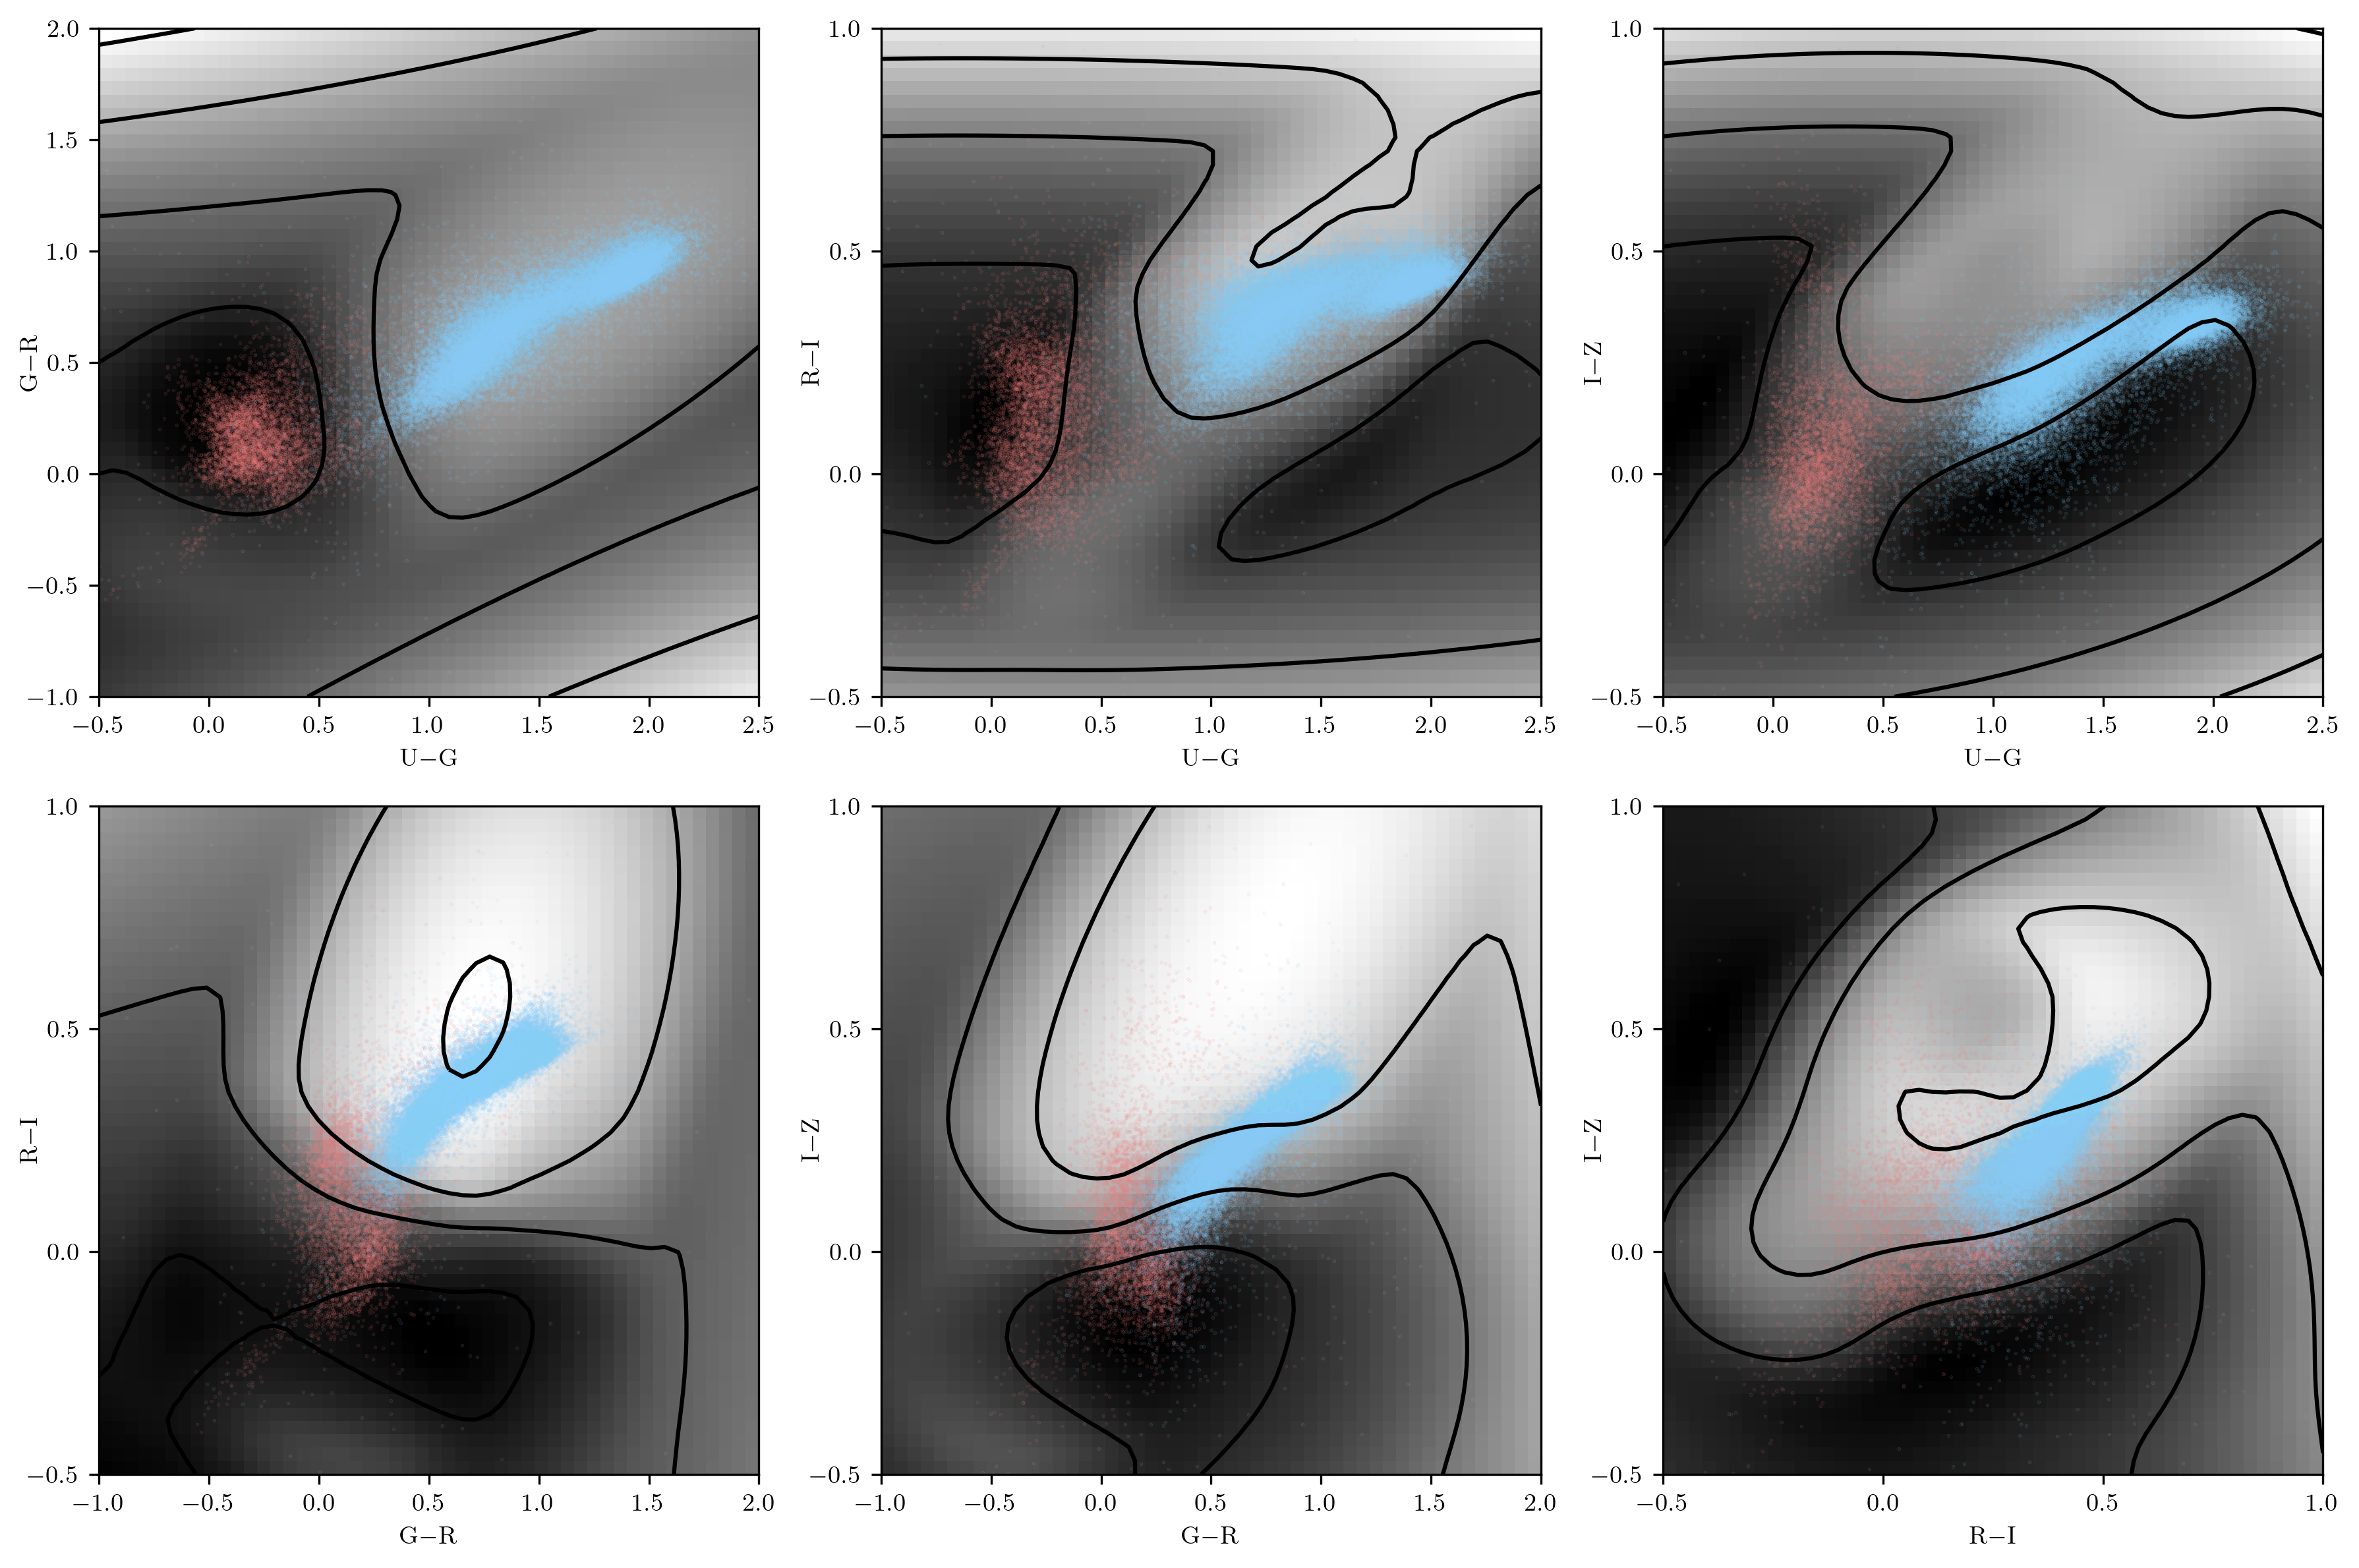

In [183]:
#-------------------------------------------------------------------------
# quick data visualization
#-------------------------------------------------------------------------

fig , ax = plt.subplots(2,3,figsize=(12,8))

axlabels = ['U$-$G', 'G$-$R', 'R$-$I', 'I$-$Z']

lims = [(-0.5,+2.5),(-1,+2),(-0.5,+1),(-0.5,+1)]

x0, x1, x2, x3 = np.meshgrid(
    np.linspace(lims[0][0], lims[0][1], 50),
    np.linspace(lims[1][0], lims[1][1], 50),
    np.linspace(lims[2][0], lims[2][1], 50),
    np.linspace(lims[3][0], lims[3][1], 50)
)
yy = classifiers_GMMBayes.predict_proba(np.c_[x0.ravel(), x1.ravel(), x2.ravel(), x3.ravel()])
# print(yy.shape)
yy = yy[:,1].reshape(x0.shape)
# print(yy.shape)
# tt = yy.sum(axis=(2,3))
# print(tt.shape)
# print(x0.shape)
# print(x0[0].shape)

for i in range(3):
    xa = np.linspace(lims[0][0], lims[0][1], 50)
    xb = np.linspace(lims[i+1][0], lims[i+1][1], 50)

    if   i==0: 
        py = yy.sum(axis=(2,3))
        ax[0,i].contour(xa, xb, py, 3, colors='k')
    elif i==1:
        py = yy.sum(axis=(1,3))
        ax[0,i].contour(xa, xb, py, 3, colors='k')
    elif i==2:
        py = yy.sum(axis=(1,2))
        ax[0,i].contour(xa, xb, py, 3, colors='k')

    im = ax[0,i].imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[0]+lims[i+1])

for i in range(2):
    xa = np.linspace(lims[1][0], lims[1][1], 50)
    xb = np.linspace(lims[i+2][0], lims[i+2][1], 50)

    if   i==0: 
        py = yy.sum(axis=(0,3))
        ax[1,i].contour(xa, xb, py, 3, colors='k')
    elif i==1:
        py = yy.sum(axis=(0,2))
        ax[1,i].contour(xa, xb, py, 3, colors='k')

    im = ax[1,i].imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[1]+lims[i+2])

xa = np.linspace(lims[2][0], lims[2][1], 50)
xb = np.linspace(lims[3][0], lims[3][1], 50)
py = yy.sum(axis=(0,1))
ax[1,2].contour(xa, xb, py, 3, colors='k')
im = ax[1,2].imshow(py, origin='lower', aspect='auto', cmap=plt.cm.binary, zorder=1, extent=lims[2]+lims[3])

#-------------------------------------------------------------------------
# plot also the data

for i in range(3):
    ax[0,i].set_xlim(lims[0])
    ax[0,i].set_ylim(lims[i+1])
    ax[0,i].set_xlabel(axlabels[0]) # , labelpad=-25)
    ax[0,i].set_ylabel(axlabels[i+1], labelpad=-5) # , labelpad=-38)
    ax[0,i].scatter(x[index_QSR,0] , x[index_QSR,i+1] , color='lightcoral', s=0.1, alpha=0.15)
    ax[0,i].scatter(x[index_GAL,0] , x[index_GAL,i+1] , color='lightskyblue', s=0.1, alpha=0.15)

for i in range(2):
    ax[1,i].set_xlim(lims[1])
    ax[1,i].set_ylim(lims[i+2])
    ax[1,i].set_xlabel(axlabels[1]) #, labelpad=-25)
    ax[1,i].set_ylabel(axlabels[i+2], labelpad=-5) #, labelpad=-38)
    ax[1,i].scatter(x[index_QSR,1] , x[index_QSR,i+2] , color='lightcoral', s=0.1, alpha=0.15)
    ax[1,i].scatter(x[index_GAL,1] , x[index_GAL,i+2] , color='lightskyblue', s=0.1, alpha=0.15)

ax[1,2].set_xlim(lims[2])
ax[1,2].set_ylim(lims[3])
ax[1,2].set_xlabel(axlabels[2]) #, labelpad=-25)
ax[1,2].set_ylabel(axlabels[3], labelpad=-5) #, labelpad=-38)
ax[1,2].scatter(x[index_QSR,2] , x[index_QSR,3] , color='lightcoral', s=0.1, alpha=0.15)
ax[1,2].scatter(x[index_GAL,2] , x[index_GAL,3] , color='lightskyblue', s=0.1, alpha=0.15)

for i in range(2):
    for j in range(3):
        ax[i,j].xaxis.set_major_locator(plt.MultipleLocator(0.5))
        ax[i,j].yaxis.set_major_locator(plt.MultipleLocator(0.5))

fig.tight_layout()

#-------------------------------------------------------------------------

In [ ]:
# note necessary but useful to remember 
# print(data_pandas['u'].to_numpy())
# print(data['u'])
# print( )
# print(data['class'])
# print(data['class'][0])
# print(data['class'][0] == 'QSO')
# print(data['class'][0] == 'GALAXY')
# print(data.shape)
# print(N_samples)